# Chapitre 7 - Introduction au Machine Learning

### 7.1 - Introduction

L'apprentissage automatique (machine learning en anglais) est un champ d'étude de l'intelligence artificielle qui vise à donner aux machines la capacité d'« apprendre » à partir de données, via des modèles mathématiques. Ce cours explore les concepts fondamentaux, les techniques de prétraitement des données, les différents types de modèles et les meilleures pratiques pour l'entraînement et l'évaluation.

### 7.2 - Types d'apprentissage

L'apprentissage automatique se divise en plusieurs catégories :

- Apprentissage supervisé : Le modèle apprend à partir d'un ensemble de données étiquetées, où chaque entrée est associée à une sortie connue. L'objectif est de prédire la sortie pour de nouvelles entrées.
- Apprentissage non supervisé : Le modèle apprend à partir de données non étiquetées, cherchant à identifier des structures ou des motifs sous-jacents dans les données.
- Apprentissage par renforcement : Le modèle apprend à interagir avec un environnement pour maximiser une récompense cumulative. Il prend des décisions basées sur des essais et des erreurs, apprenant de ses actions passées.

### 7.2 - Types d'apprentissage

#### Classification - [Le dataset Iris](https://www.kaggle.com/datasets/uciml/iris)

Nous allons étudier le dataset Iris, le plus communément utilisé pour illustrer les algorithmes de classification. Il contient 150 échantillons de fleurs d'iris, chacun décrit par quatre caractéristiques : la longueur et la largeur des sépales et des pétales. Les échantillons sont répartis en trois espèces : Iris Setosa, Iris Versicolor et Iris Virginica.

Nous allons observer rapidement l'apprentissage non supervisé

In [ ]:
import pandas as pd

iris_df = pd.read_csv("data/iris_dataset.csv")

# renomons les colonnes
iris_df = iris_df.rename(
    columns={
        "SepalLengthCm": "sepal_length",
        "SepalWidthCm": "sepal_width",
        "PetalLengthCm": "petal_length",
        "PetalWidthCm": "petal_width",
        "Species": "species",
    }
)

iris_df.head()

In [ ]:
iris_df["species"].unique()

In [ ]:
# Affichons les iris
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]

# Scatter plot pour chaque espèce
for k, species in enumerate(iris_df["species"].unique()):
    subset = iris_df[iris_df["species"] == species]
    plt.scatter(
        subset["sepal_length"], subset["sepal_width"], label=species, color=colors[k]
    )
plt.title("Iris Dataset - Sepal Length vs Sepal Width")
plt.xlabel("Longueur du sépale (cm)")
plt.ylabel("Largeur du sépale (cm)")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]

# Scatter plot pour chaque espèce
for k, species in enumerate(iris_df["species"].unique()):
    subset = iris_df[iris_df["species"] == species]
    plt.scatter(
        subset["petal_length"], subset["petal_width"], label=species, color=colors[k]
    )
plt.title("Iris Dataset - Petal Length vs Petal Width")
plt.xlabel("Longueur du pétale (cm)")
plt.ylabel("Largeur du pétale (cm)")
plt.legend()
plt.show()

##### Apprentissage non supervisé

In [ ]:
# Appliquer les KMeans
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import mode

kmeans = KMeans(n_clusters=3, random_state=42)

# On ne garde que les colonnes numériques
kmeans.fit(iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]])

# Assign the cluster labels to the dataframe
iris_df["kmeans_labels"] = kmeans.labels_

In [ ]:
kmeans

In [ ]:
kmeans.labels_

In [ ]:
# Map species to numerical values
species_mapping = {"Iris-setosa": 1, "Iris-versicolor": 2, "Iris-virginica": 0}
iris_df["species_num"] = iris_df["species"].map(species_mapping)

iris_df.head()

In [ ]:
score = np.mean(iris_df["kmeans_labels"] == iris_df["species_num"])
print(f"Score: {score:.2f}")

In [ ]:
kmeans.cluster_centers_

In [ ]:
df_cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"],
)
df_cluster_centers.head()

In [ ]:
# Afficher sur un graphique les clusters

plt.figure(figsize=(8, 5))
# Suplot : 1 pour les pétales, 2 pour les sépales
plt.subplot(2, 1, 1)
plt.scatter(
    iris_df["petal_length"],
    iris_df["petal_width"],
    c=iris_df["kmeans_labels"],
    cmap="viridis",
)
# Add centroids
plt.scatter(
    df_cluster_centers["petal_length"],
    df_cluster_centers["petal_width"],
    s=50,
    c="red",
    marker="X",
    label="Centroids",
)
plt.title("Clusters KMeans - Pétales")
plt.xlabel("Longueur du pétale (cm)")
plt.ylabel("Largeur du pétale (cm)")

plt.subplot(2, 1, 2)
plt.scatter(
    iris_df["sepal_length"],
    iris_df["sepal_width"],
    c=iris_df["kmeans_labels"],
    cmap="viridis",
)
# Add centroids
plt.scatter(
    df_cluster_centers["sepal_length"],
    df_cluster_centers["sepal_width"],
    s=50,
    c="red",
    marker="X",
    label="Centroids",
)
plt.title("Clusters KMeans - Sépales")
plt.xlabel("Longueur du sépale (cm)")
plt.ylabel("Largeur du sépale (cm)")
plt.tight_layout()
plt.show()

In [ ]:
iris_df["is_predicted"] = iris_df["kmeans_labels"] == iris_df["species_num"]
iris_df.head()

# Montrer les valeurs correctement prédites et incorrectement prédites, on se basera uniquement sur les sépales
plt.figure(figsize=(8, 5))
plt.scatter(
    iris_df[iris_df["is_predicted"] == True]["sepal_length"],
    iris_df[iris_df["is_predicted"] == True]["sepal_width"],
    label="Correctement prédit",
    color="green",
)
plt.scatter(
    iris_df[iris_df["is_predicted"] == False]["sepal_length"],
    iris_df[iris_df["is_predicted"] == False]["sepal_width"],
    label="Incorrectement prédit",
    color="red",
)
plt.title("Prédictions KMeans - Sépales")
plt.xlabel("Longueur du sépale (cm)")
plt.ylabel("Largeur du sépale (cm)")
plt.legend()
plt.show()

##### Apprentissage supervisé



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
iris_df

In [ ]:
help(train_test_split)

In [ ]:
# Use KNN
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Séparer les données en ensembles d'entraînement et de test
col = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris_df[col]
y = iris_df["species_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [ ]:
y_train

In [ ]:
X_train

In [ ]:
# Créer le classificateur KNN: On sait à l'avance que 3 est le bon nombre de voisins, dans la vraie vie, il faut le tester
knn = KNeighborsClassifier(n_neighbors=4)

# Entraîner le modèle
knn.fit(X_train, y_train)

In [ ]:
# Prédire les classes sur l'ensemble de test
y_pred = knn.predict(X_test)

y_pred

In [ ]:
# Afficher le score
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)
print(f"Score KNN: {score:.2f}")

In [ ]:
# Afficher les résultats
res = X_test.copy()
res["actual"] = y_test
res["predicted"] = y_pred

res["is_predicted"] = res["actual"] == res["predicted"]

In [ ]:
# Afficher les valeurs correctement prédites et incorrectement prédites, on se basera uniquement sur les sépales
plt.figure(figsize=(8, 5))
plt.scatter(
    res[res["is_predicted"] == True]["sepal_length"],
    res[res["is_predicted"] == True]["sepal_width"],
    label="Correctement prédit",
    color="green",
)
plt.scatter(
    res[res["is_predicted"] == False]["sepal_length"],
    res[res["is_predicted"] == False]["sepal_width"],
    label="Incorrectement prédit",
    color="red",
)
plt.title("Prédictions KNN - Sépales")
plt.xlabel("Longueur du sépale (cm)")
plt.ylabel("Largeur du sépale (cm)")
plt.legend()
plt.show()

In [ ]:
# Le modele a correctement prédit 100% des iris

# Use only two features for visualization
from matplotlib.colors import ListedColormap


col_visualization = ["petal_length", "petal_width"]
X_vis = iris_df[col_visualization]
y = iris_df["species_num"]

# Separate the data into training and test sets using only the two features
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)

# Create the KNN classifier with only two features
knn_vis = KNeighborsClassifier(n_neighbors=4)

# Train the model with only two features
knn_vis.fit(X_train_vis, y_train_vis)

# Predict the classes on the test set with only two features
y_pred_vis = knn_vis.predict(X_test_vis)

# Create a mesh to plot the decision boundary
x_min, x_max = X_vis["petal_length"].min() - 1, X_vis["petal_length"].max() + 1
y_min, y_max = X_vis["petal_width"].min() - 1, X_vis["petal_width"].max() + 1
x_mesh, y_mesh = np.meshgrid(
    np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01)
)

# Predict classifications for each point in the mesh
Z = knn_vis.predict(np.c_[x_mesh.ravel(), y_mesh.ravel()])
Z = Z.reshape(x_mesh.shape)

# Create a color map
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(x_mesh, y_mesh, Z, cmap=cmap_light, alpha=0.8)

# Plot the training points
plt.scatter(
    X_train_vis["petal_length"],
    X_train_vis["petal_width"],
    c=y_train_vis,
    cmap=cmap_bold,
    edgecolor="k",
    s=20,
    marker="o",
)
plt.scatter(
    X_test_vis["petal_length"],
    X_test_vis["petal_width"],
    c=y_test_vis,
    cmap=cmap_bold,
    edgecolor="k",
    s=80,
    marker="^",
)

plt.xlim(x_mesh.min(), x_mesh.max())
plt.ylim(y_mesh.min(), y_mesh.max())
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.title("KNN Decision Boundary with k=4")
plt.show()

In [ ]:
iris_df.species.unique()

In [ ]:
mapping = {"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2}

In [ ]:
mapping["Iris-setosa"]

In [ ]:
iris_df["species_numeric"] = iris_df["species"].apply(lambda x: mapping[x])

In [ ]:
iris_df

### Exercice 🐍 - Arbre de décision

Dans cet exercice, nous allons utiliser un arbre de décision pour classer les fleurs d'iris. Nous allons charger le dataset, diviser les données en ensembles d'entraînement et de test, entraîner un modèle d'arbre de décision et évaluer sa performance.

### Objectifs
- Comprendre le fonctionnement d'un arbre de décision
- Apprendre à évaluer la performance d'un modèle de classification
- Utiliser la bibliothèque `scikit-learn` pour construire et évaluer un modèle d'arbre de décision

### Enoncé

1. Importer le module `DecisionTreeClassifier` de `sklearn.tree`.
2. Lire le dataset Iris à l'aide de `pandas`.
3. Diviser le dataset en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test).
4. Créer un modèle d'arbre de décision et l'entraîner sur l'ensemble d'entraînement.
5. Prédire les classes sur l'ensemble de test.
6. Évaluer la performance du modèle en utilisant la précision (accuracy) et le rapport de classification (classification report).
7. Visualiser l'arbre de décision à l'aide de `plot_tree` de `sklearn.tree`.


In [ ]:
# A vous de jouer !

### Regression

La régression est une technique d'apprentissage supervisé utilisée pour prédire une valeur continue. Contrairement à la classification, où les sorties sont des catégories discrètes (e.g. 1 ou 0, ou des catégories), la régression vise à établir une relation entre les variables indépendantes et la variable dépendante continue.

#### La régression est le sujet du projet Python

On va étudier pas à pas le processus de régression:
- Visualisation des données
- Prétraitement des données (Feature engineering)
- Feature importance / feature selection
- Modélisation
- Évaluation du modèle

Les variables du Boston housing dataset sont les suivantes :
- CRIM - taux de criminalité par habitant par ville
- ZN - proportion de terrains résidentiels zonés pour des lots de plus de 25 000 pieds carrés.
- INDUS - proportion d'acres d'entreprises autres que de vente au détail par ville.
- CHAS - Variable muette Charles River (1 si la parcelle longe la rivière ; 0 sinon)
- NOX - concentration d'oxydes nitriques (parties par 10 millions)
- RM - nombre moyen de pièces par logement
- AGE - proportion de logements occupés par leur propriétaire et construits avant 1940
- DIS - distances pondérées par rapport à cinq centres d'emploi de Boston
- RAD - indice d'accessibilité aux autoroutes radiales
- TAX - taux d'imposition sur la pleine valeur de la propriété pour 10 000 dollars
- PTRATIO - taux d'encadrement par ville
- B - 1000(Bk - 0,63)^2 où Bk est la proportion de Noirs par ville
- LSTAT - % de la population de statut inférieur
- MEDV - Valeur médiane des maisons occupées par leur propriétaire en milliers de dollars

On cherchera à prédire : **medv**

In [9]:
# On va utiliser les données BostonHousing
import pandas as pd

df = pd.read_csv("data/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [3]:
# Y a t-il des valeurs manquantes ?
df.isnull().sum(axis=0)

# - RM - nombre moyen de pièces par logement: 5 valeurs manquantes

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [4]:
# df["rm"] = df["rm"].fillna(0)
# df[df["rm"] == 0]

##### Remplacer les valeurs manquantes: Il existe plusieurs méthodes pour remplacer les valeurs manquantes, mais la plus simple est de remplacer par la moyenne de la colonne. On peut aussi remplacer les valeurs manquantes par la médiane ou encore par des valeurs fixes (0 par exemple).

In [10]:
# Remplacer les valeurs manquantes par la moyenne
df["rm"] = df["rm"].fillna(df["rm"].mean())
df.isnull().sum(axis=0)

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [16]:
df["medv"]

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64

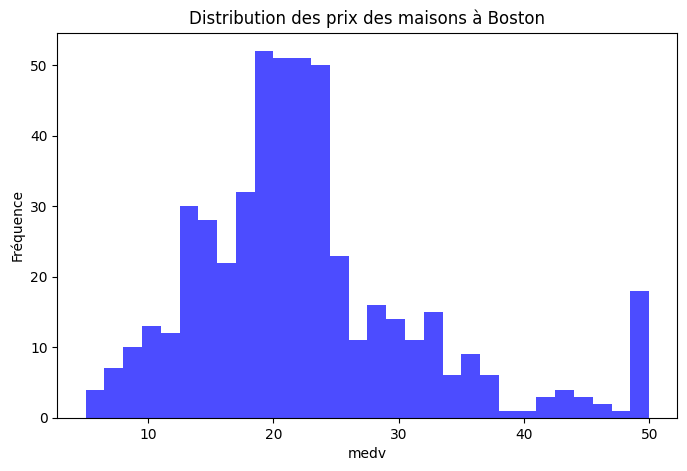

In [17]:
# On peut afficher la répartition des prix
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["medv"], bins=30, color="blue", alpha=0.7)
plt.title("Distribution des prix des maisons à Boston")
plt.xlabel("medv")
plt.ylabel("Fréquence")
plt.show()

On va entrainer le modèle sur l'ensemble d'entraînement et le tester sur l'ensemble de test. On va aussi évaluer la performance du modèle en utilisant la métrique RMSE (Root Mean Squared Error) et R² (coefficient de détermination).

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["medv"])
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
X_train

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.4640,5.856,42.1,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.4350,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.7400,6.629,94.6,2.1247,24,666,20.2,109.85,23.27


In [21]:
from sklearn.linear_model import LinearRegression

# Créer le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle
model.fit(X_train, y_train)

# Afficher les coefficients du modèle
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coefficients

,Coefficient
crim,-0.113051
zn,0.030209
indus,0.041726
chas,2.787586
nox,-17.188929
rm,4.429193
age,-0.006109
dis,-1.442141
rad,0.262753
tax,-0.010647


In [24]:
y_pred = model.predict(X_test)

# Afficher les résultats & les comparer avec les valeurs réelles
results = X_test.copy()
results["actual"] = y_test
results["predicted"] = y_pred

results.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,actual,predicted
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04,23.6,28.981419
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53,32.4,36.014232
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07,13.6,14.824309
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52,22.8,25.022936
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27,16.1,18.770774


L'ordre des index est donc primordial, on se base sur la structure ordonnée des DataFrame de pandas pour être certain d'associer les prédictions aux valeurs réelles correspondantes.


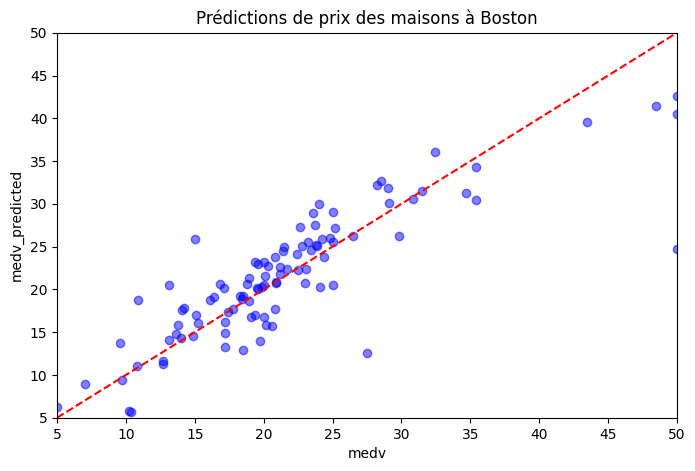

In [28]:
# Afficher les résultats
plt.figure(figsize=(8, 5))
plt.scatter(results["actual"], results["predicted"], color="blue", alpha=0.5)
plt.plot(
    [results["actual"].min(), results["actual"].max()],
    [results["actual"].min(), results["actual"].max()],
    color="red",
    linestyle="--",
)
plt.title("Prédictions de prix des maisons à Boston")
plt.xlabel("medv")
plt.ylabel("medv_predicted")
plt.xlim(results["actual"].min(), results["actual"].max())
plt.ylim(results["actual"].min(), results["actual"].max())
plt.show()

### Exercice 🐍 - Arbre de décision

Dans cet exercice, nous allons utiliser un arbre de décision pour prédire la valeur médiane des maisons à Boston. Nous allons charger le dataset, diviser les données en ensembles d'entraînement et de test, entraîner un modèle de forêt aléatoire et évaluer sa performance.

### Objectifs
- Utiliser la bibliothèque `scikit-learn` pour construire et évaluer un modèle de forêt aléatoire

### Enoncé

1. Importer le module `DecisionTreeRegressor` de `sklearn.tree`.
2. Séparation des données en ensembles d'entraînement et de test (80% pour l'entraînement, 20% pour le test).
3. Créer un modèle de forêt aléatoire et l'entraîner sur l'ensemble d'entraînement.
4. Prédire les valeurs sur l'ensemble de test.
5. Visualiser les résultats de la prédiction en traçant un nuage de points entre les valeurs prédites et les valeurs réelles.

In [ ]:
# A vous de jouer !

### Calcul du score de régression

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# R2: R2 est le coefficient de détermination, qui mesure la proportion de la variance des prix expliquée par le modèle
# Plus R2 est proche de 1, meilleur est le modèle
r2_score = model.score(X_test, y_test)
print(f"R² score: {r2_score:.2f}")

# MAE: L'erreur absolue moyenne (MAE) mesure la moyenne des erreurs absolues entre les valeurs prédites et réelles
# Plus la MAE est faible, meilleur est le modèle
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

# RMSE: La racine carrée de l'erreur quadratique moyenne (RMSE) mesure la moyenne des erreurs au carré entre les valeurs
# prédites et réelles
# Plus la RMSE est faible, meilleur est le modèle
rmse = mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")

R² score: 0.67
MAE: 3.21
RMSE: 24.40


### Exercice 🐍 - Comparer les scores des modèles

Dans cet exercice, nous allons comparer les performances des deux modèles de régression que nous avons construits : la régression et l'arbre de décision. Nous allons évaluer les deux modèles en utilisant les métriques R², RMSE et MAE (Mean Absolute Error).

### Objectifs
- Comparer les performances des deux modèles de régression

### Enoncé
1. Calculer le R², la RMSE et le MAE (Mean Absolute Error) pour le modèle de l'arbre de décision.
2. Comparer les résultats avec ceux du modèle de régression.
3. Déduire quel modèle est le meilleur pour prédire la valeur médiane des maisons à Boston.

In [ ]:
# A vous de jouer !

Ici, nous avons entrainé le modèle "naivement" sur les données brutes, sans les traiter. Nous allons maintenant voir comment améliorer les performances du modèle en effectuant un prétraitement des données.

### 🐍 Dans la suite, nous allons voir pas à pas comment améliorer le modèle de régression.

Rappel:
- **CRIM** : Taux de criminalité par habitant dans la ville. Plus ce taux est élevé, moins le quartier est sûr.
- **ZN** : Proportion de terrains résidentiels zonés pour de grandes parcelles (plus de 25 000 pieds carrés). Cela indique la disponibilité de grands terrains résidentiels.
- **INDUS** : Proportion d'acres occupés par des entreprises non commerciales par ville. Cela montre la présence d'industries dans la ville.
- **CHAS** : Variable indicatrice pour la rivière Charles. Elle vaut 1 si la propriété est située le long de la rivière et 0 sinon.
- **NOX** : Concentration en oxydes nitriques (en parties par 10 millions). C'est un indicateur de la pollution de l'air.
- **RM** : Nombre moyen de pièces par logement. Plus ce nombre est élevé, plus les logements sont spacieux.
- **AGE** : Proportion de logements construits avant 1940 et occupés par leurs propriétaires. Cela donne une idée de l'âge des logements dans le quartier.
- **DIS** : Distances pondérées par rapport à cinq centres d'emploi de Boston. Cela mesure l'accessibilité aux emplois.
- **RAD** : Indice d'accessibilité aux autoroutes radiales. Plus l'indice est élevé, plus l'accès aux autoroutes est facile.
- **TAX** : Taux d'imposition foncière pour une propriété évaluée à 10 000 dollars. Cela indique le niveau de taxation dans la ville.
- **PTRATIO** : Ratio élèves-enseignants par ville. Un ratio plus bas peut indiquer une meilleure qualité de l'éducation.
- **B** : Calcul basé sur la proportion de personnes d'origine afro-américaine dans la ville. Bk est la proportion de personnes noires.
- **LSTAT** : Pourcentage de la population considérée comme ayant un statut socio-économique inférieur. Cela peut refléter le niveau économique général de la région.
- **MEDV** : Valeur médiane des maisons occupées par leurs propriétaires, en milliers de dollars. C'est la variable cible que l'on cherche souvent à prédire.

In [46]:
import pandas as pd

df = pd.read_csv("data/BostonHousing.csv")

#### ​​✂️​ Pré traitement des données

Le prétraitement des données est une étape cruciale dans le processus de machine learning. Il permet de préparer les données brutes pour l'entraînement du modèle, en nettoyant, et normalisant les données, en gérant les valeurs manquantes

In [47]:
# Separate features and target
df_x = df.drop(columns=["medv"])
y = df["medv"]

In [48]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [49]:
df_x[df_x["rm"].isnull()]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
10,0.22489,12.5,7.87,0,0.524,NaN,94.3,6.3467,5,311,15.2,392.52,20.45
35,0.06417,0.0,5.96,0,0.499,NaN,68.2,3.3603,5,279,19.2,396.90,9.68
63,0.12650,25.0,5.13,0,0.453,NaN,43.4,7.9809,8,284,19.7,395.58,9.50
96,0.11504,0.0,2.89,0,0.445,NaN,69.6,3.4952,2,276,18.0,391.83,11.34
135,0.55778,0.0,21.89,0,0.624,NaN,98.2,2.1107,4,437,21.2,394.67,16.96


In [53]:
# Cette variable est la moyenne du nombre de pièces par logement
# On va remplacer les valeurs manquantes par la moyenne de cette variable

df["rm"] = df["rm"].fillna(df["rm"].mean())

In [51]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


#### 🧪 Feature Engineering

Le feature engineering est le processus de création de nouvelles caractéristiques à partir des données existantes. Cela peut inclure la transformation de variables, la création d'interactions entre variables, ou l'extraction de caractéristiques à partir de données brutes.

In [54]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# Feature 1: Average rooms per residential land proportion
df["avg_rooms_per_land_proportion"] = df["rm"] / (
    df["zn"] + 1
)  # Adding 1 to avoid division by zero

# Feature 2: On va créer des features polynomiales pour les
# variables "rm", "lstat" et "tax"
# Cela veut dire ajouter les interactions entre ces variables
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features = poly.fit_transform(df[["rm", "lstat", "tax"]])
poly_feature_names = poly.get_feature_names_out(["rm", "lstat", "tax"])
df_poly = pd.DataFrame(poly_features, columns=poly_feature_names)

# Concatenate the polynomial features with the original dataframe
df = df.drop(
    columns=["rm", "lstat", "tax"]
)  # Drop original features to avoid redundancy
df = pd.concat([df, df_poly], axis=1)

# Log transformation for skewed features
df["log_crim"] = np.log1p(df["crim"])
df["log_lstat"] = np.log1p(df["lstat"])

In [55]:
df.head()

,crim,zn,indus,chas,nox,age,dis,rad,ptratio,b,medv,avg_rooms_per_land_proportion,rm,lstat,tax,rm lstat,rm tax,lstat tax,log_crim,log_lstat
0,0.00632,18.0,2.31,0,0.538,65.2,4.0900,1,15.3,396.90,24.0,0.346053,6.575,4.98,296.0,32.74350,1946.200,1474.08,0.006300,1.788421
1,0.02731,0.0,7.07,0,0.469,78.9,4.9671,2,17.8,396.90,21.6,6.421000,6.421,9.14,242.0,58.68794,1553.882,2211.88,0.026944,2.316488
2,0.02729,0.0,7.07,0,0.469,61.1,4.9671,2,17.8,392.83,34.7,7.185000,7.185,4.03,242.0,28.95555,1738.770,975.26,0.026924,1.615420
3,0.03237,0.0,2.18,0,0.458,45.8,6.0622,3,18.7,394.63,33.4,6.998000,6.998,2.94,222.0,20.57412,1553.556,652.68,0.031857,1.371181
4,0.06905,0.0,2.18,0,0.458,54.2,6.0622,3,18.7,396.90,36.2,7.147000,7.147,5.33,222.0,38.09351,1586.634,1183.26,0.066770,1.845300


On va normaliser les données afin de les rendre comparables, d'améliorer les performances des modèles et de faciliter la convergence des algorithmes d'optimisation.

In [56]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["medv"]))
df_scaled = pd.DataFrame(df_scaled, columns=df.drop(columns=["medv"]).columns)
df = df_scaled.copy()
df["medv"] = y

In [57]:
df_x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [58]:
df.head()

,crim,zn,indus,chas,nox,age,dis,rad,ptratio,b,avg_rooms_per_land_proportion,rm,lstat,tax,rm lstat,rm tax,lstat tax,log_crim,log_lstat,medv
0,0.000000,0.18,0.067815,0.0,0.314815,0.641607,0.269203,0.000000,0.287234,1.000000,0.031973,0.577505,0.089680,0.208015,0.104722,0.185917,0.039337,0.000000,0.294949,24.0
1,0.000236,0.00,0.242302,0.0,0.172840,0.782698,0.348962,0.043478,0.553191,1.000000,0.729240,0.547998,0.204470,0.104962,0.242029,0.104051,0.069100,0.004594,0.493583,21.6
2,0.000236,0.00,0.242302,0.0,0.172840,0.599382,0.348962,0.043478,0.553191,0.989737,0.816930,0.694386,0.063466,0.104962,0.084675,0.142632,0.019214,0.004590,0.229874,34.7
3,0.000293,0.00,0.063050,0.0,0.150206,0.441813,0.448545,0.086957,0.648936,0.994276,0.795467,0.658555,0.033389,0.066794,0.040318,0.103983,0.006201,0.005688,0.138003,33.4
4,0.000705,0.00,0.063050,0.0,0.150206,0.528321,0.448545,0.086957,0.648936,1.000000,0.812568,0.687105,0.099338,0.066794,0.133036,0.110886,0.027605,0.013458,0.316344,36.2


#### 🌳 Importance des variables

La feature importance est une mesure de l'importance relative de chaque caractéristique dans la prédiction de la variable cible. Elle peut être utilisée pour sélectionner les caractéristiques les plus pertinentes et améliorer la performance du modèle.

Elle peut être utilisée conjointement à l'étude de corrélations.

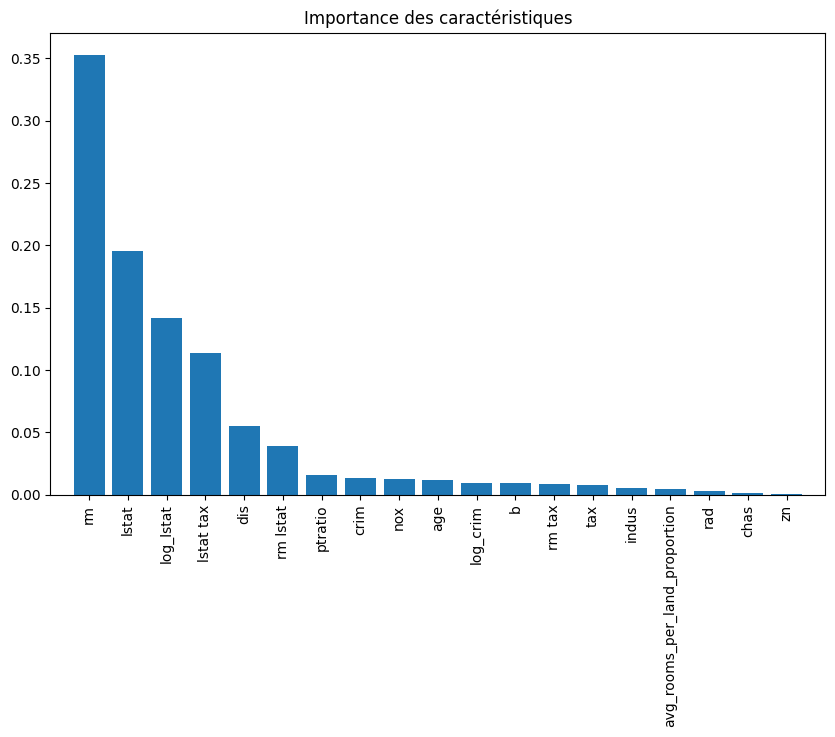

In [59]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.drop(columns=["medv"])
y = df["medv"]

# Créer le modèle de forêt aléatoire
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entraîner le modèle
model.fit(X, y)

# Importance des caractéristiques
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Afficher les caractéristiques les plus importantes
plt.figure(figsize=(10, 6))
plt.title("Importance des caractéristiques")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

Ici on observe les variables ayant le plus de relation avec la variable cible. Avec l'approche ensembliste, on capture également les relations non linéaires entre les variables. On peut donc s'attendre à ce que ces variables aient une importance élevée dans le modèle de régression.

In [60]:
# On va sélectionner les caractéristiques les plus importantes
# Avec une importance supérieure à 0.001
min_importance = 0.001
top_features = feature_names[indices][importances[indices] > min_importance]

In [61]:
top_features

Index(['rm', 'lstat', 'log_lstat', 'lstat tax', 'dis', 'rm lstat', 'ptratio',
       'crim', 'nox', 'age', 'log_crim', 'b', 'rm tax', 'tax', 'indus',
       'avg_rooms_per_land_proportion', 'rad'],
      dtype='object')

In [62]:
X_features = df[top_features]

In [63]:
X_features.head()

,rm,lstat,log_lstat,lstat tax,dis,rm lstat,ptratio,crim,nox,age,log_crim,b,rm tax,tax,indus,avg_rooms_per_land_proportion,rad
0,0.577505,0.089680,0.294949,0.039337,0.269203,0.104722,0.287234,0.000000,0.314815,0.641607,0.000000,1.000000,0.185917,0.208015,0.067815,0.031973,0.000000
1,0.547998,0.204470,0.493583,0.069100,0.348962,0.242029,0.553191,0.000236,0.172840,0.782698,0.004594,1.000000,0.104051,0.104962,0.242302,0.729240,0.043478
2,0.694386,0.063466,0.229874,0.019214,0.348962,0.084675,0.553191,0.000236,0.172840,0.599382,0.004590,0.989737,0.142632,0.104962,0.242302,0.816930,0.043478
3,0.658555,0.033389,0.138003,0.006201,0.448545,0.040318,0.648936,0.000293,0.150206,0.441813,0.005688,0.994276,0.103983,0.066794,0.063050,0.795467,0.086957
4,0.687105,0.099338,0.316344,0.027605,0.448545,0.133036,0.648936,0.000705,0.150206,0.528321,0.013458,1.000000,0.110886,0.066794,0.063050,0.812568,0.086957


<Axes: >

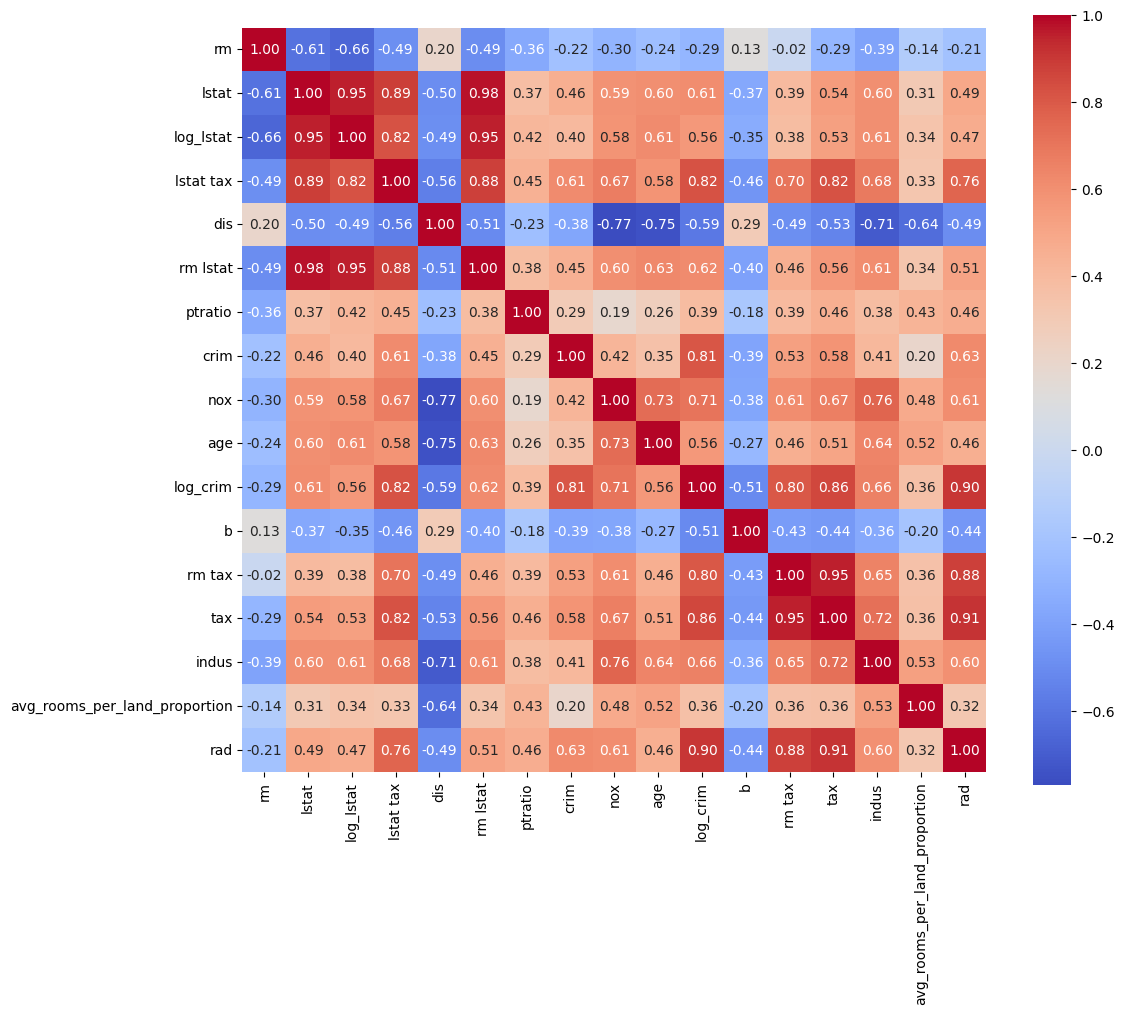

In [64]:
# Correlation
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = X_features.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

Ici on observe la matrice de corrélations entre les variables sélectionnée. Il ne faut pas avoir de corrélations trop élevées entre les variables, sinon on risque d'avoir des problèmes de multicolinéarité. On va donc essayer de réduire le nombre de variables en supprimant celles qui sont trop corrélées entre elles.

In [65]:
# On retire donc la variable ltat_log qui est très corrélée avec lstat
X_features_selected = X_features.drop(
    columns=["log_lstat", "rm lstat", "rm tax", "rad"], axis=1
)

In [66]:
X_features_selected.head()

,rm,lstat,lstat tax,dis,ptratio,crim,nox,age,log_crim,b,tax,indus,avg_rooms_per_land_proportion
0,0.577505,0.089680,0.039337,0.269203,0.287234,0.000000,0.314815,0.641607,0.000000,1.000000,0.208015,0.067815,0.031973
1,0.547998,0.204470,0.069100,0.348962,0.553191,0.000236,0.172840,0.782698,0.004594,1.000000,0.104962,0.242302,0.729240
2,0.694386,0.063466,0.019214,0.348962,0.553191,0.000236,0.172840,0.599382,0.004590,0.989737,0.104962,0.242302,0.816930
3,0.658555,0.033389,0.006201,0.448545,0.648936,0.000293,0.150206,0.441813,0.005688,0.994276,0.066794,0.063050,0.795467
4,0.687105,0.099338,0.027605,0.448545,0.648936,0.000705,0.150206,0.528321,0.013458,1.000000,0.066794,0.063050,0.812568


<Axes: >

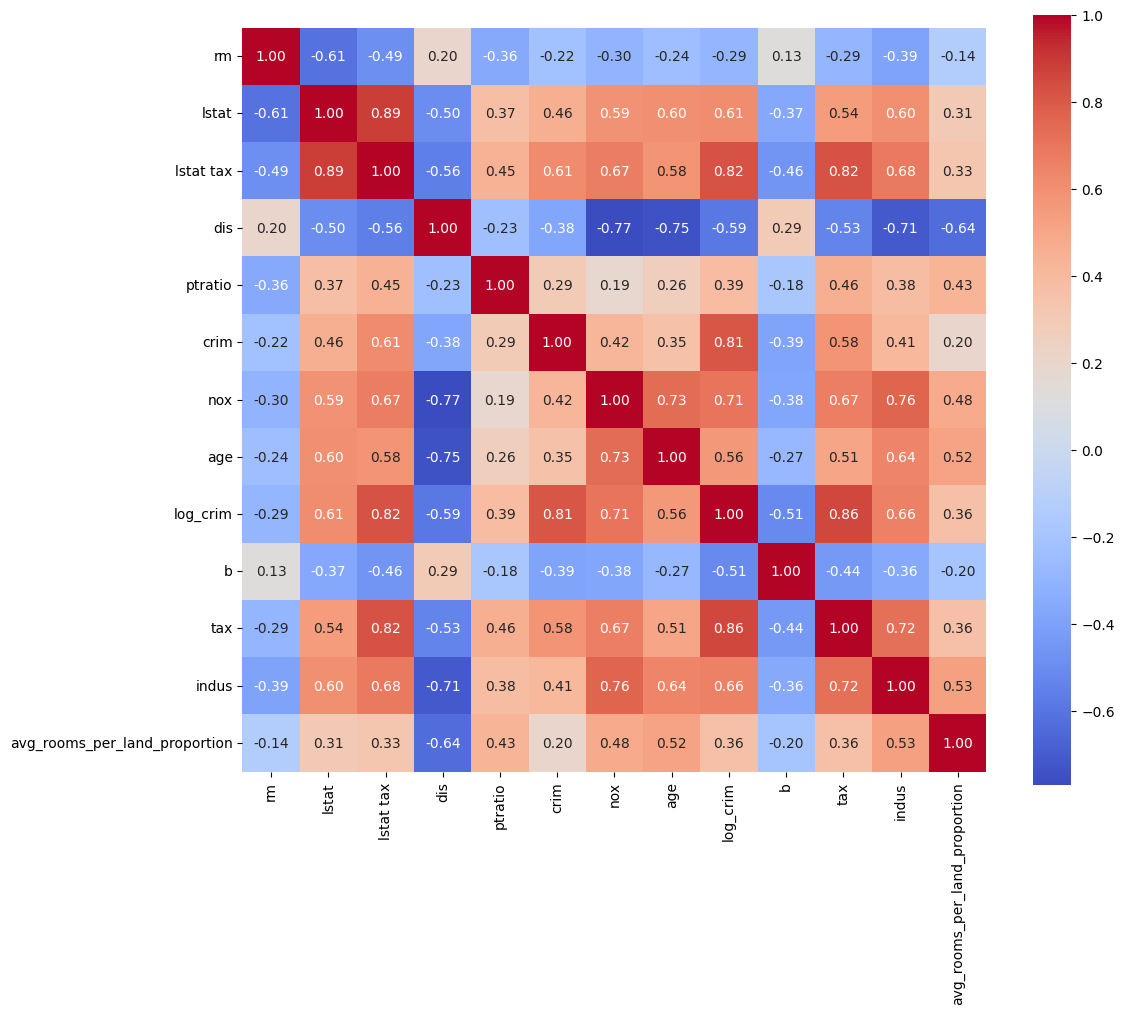

In [67]:
correlation_matrix = X_features_selected.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

#### 📈 Modélisation / Prédiction

On a donc ajouté des variables dans le processus de feature engineering & sélectionné les variables les plus importantes. On va maintenant entrainer le modèle sur l'ensemble d'entraînement et le tester sur l'ensemble de test. On va aussi évaluer la performance du modèle en utilisant la métrique RMSE (Root Mean Squared Error) et R² (coefficient de détermination).

In [68]:
from sklearn.tree import DecisionTreeRegressor

X = df.drop(columns=["medv"], axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X_features_selected, y, test_size=0.2, random_state=42
)

# Créer le modèle de forêt aléatoire
model = DecisionTreeRegressor(random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

# Prédire les prix sur l'ensemble de test
y_pred = model.predict(X_test)

# Afficher les résultats & les comparer avec les valeurs réelles
results = X_test.copy()
results["actual"] = y_test
results["predicted"] = y_pred
results.head()

,rm,lstat,lstat tax,dis,ptratio,crim,nox,age,log_crim,b,tax,indus,avg_rooms_per_land_proportion,actual,predicted
173,0.547040,0.201711,0.087816,0.137921,0.425532,0.000961,0.257202,0.836251,0.018140,0.996470,0.208015,0.131598,0.728666,23.6,23.0
274,0.612569,0.049669,0.016042,0.268076,0.531915,0.000563,0.127572,0.308960,0.010817,1.000000,0.127863,0.218109,0.011173,32.4,31.6
491,0.464074,0.450883,0.498156,0.067155,0.797872,0.001117,0.460905,0.987642,0.020968,0.982879,1.000000,1.000000,0.678968,13.6,20.5
72,0.479785,0.104581,0.047789,0.378079,0.702128,0.000959,0.057613,0.050463,0.018112,0.984896,0.225191,0.379399,0.688379,22.8,21.2
452,0.524238,0.428808,0.443860,0.112632,0.808511,0.057141,0.674897,0.915551,0.400685,0.970220,0.914122,0.646628,0.715008,16.1,12.6


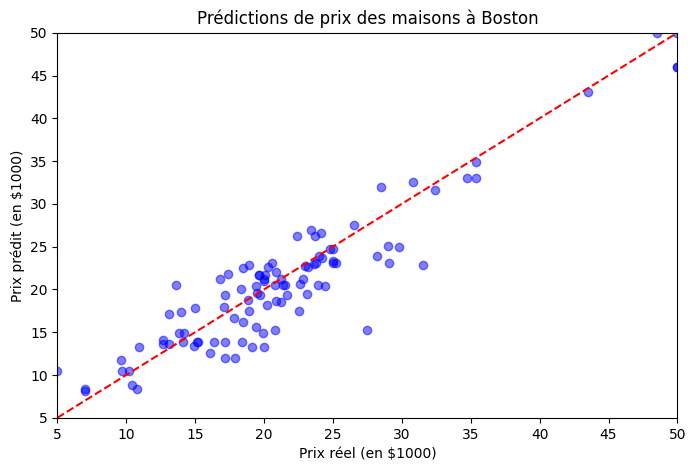

In [69]:
# Afficher les résultats
plt.figure(figsize=(8, 5))
plt.scatter(results["actual"], results["predicted"], color="blue", alpha=0.5)
plt.plot(
    [results["actual"].min(), results["actual"].max()],
    [results["actual"].min(), results["actual"].max()],
    color="red",
    linestyle="--",
)
plt.title("Prédictions de prix des maisons à Boston")
plt.xlabel("Prix réel (en $1000)")
plt.ylabel("Prix prédit (en $1000)")
plt.xlim(results["actual"].min(), results["actual"].max())
plt.ylim(results["actual"].min(), results["actual"].max())
plt.show()

In [70]:
# Métriques de performance

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# R2
r2_score = model.score(X_test, y_test)
print(f"R² score: {r2_score:.2f}")

# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

# RMSE
rmse = mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")

R² score: 0.86
MAE: 2.46
RMSE: 10.28


On peut encore améliorer les performances en utilisant des modèles plus complexes, en ajustant les hyperparamètres du modèle, ou en utilisant des techniques d'optimisation avancées...

### Exercice 🐍 - Utilisation d'un modèle plus complexe

Dans cet exercice, nous allons utiliser un modèle de régression plus complexe pour prédire la valeur médiane des maisons à Boston. Nous allons charger le dataset, diviser les données en ensembles d'entraînement et de test, entraîner un modèle de forêt aléatoire et évaluer sa performance.

### Objectifs
- Utiliser la bibliothèque `scikit-learn` pour construire et évaluer un modèle de forêt aléatoire

### Enoncé
1. Importer le module `RandomForestRegressor` de `sklearn.ensemble`.
2. Prédire les valeurs sur l'ensemble de test.
3. Visualiser les résultats de la prédiction en traçant un nuage de points entre les valeurs prédites et les valeurs réelles.
4. Calculer le R², la RMSE et le MAE pour le modèle de forêt aléatoire et comparer les résultats avec ceux du ``DecisionTreeRegressor``

In [ ]:
# A vous de jouer !